Some basic checks on the raw data using katdal

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 
import katdal as kd

In [2]:
#d = kd.open('/idia/projects/meerklass/MEERKLASS-1/uhf_data/XLP2025/raw/1745260482/1745260482/1745260482_sdp_l0.full.rdb')
#base_folder='/idia/projects/meerklass/MEERKLASS-1/uhf_data/XLP2025/raw/'
#base_folder='/idia/projects/meerklass/MEERKLASS-1/SCI-20220822-MS-01/'
base_folder='/home/mgrsantos/projects/data/blocks/'
#block='1723133487'
#block='1745260482'
block='1675021905'
#block='1675632179'


In [3]:
d = kd.open(base_folder + block + '/' + block + '/' + block + '_sdp_l0.full.rdb')

In [4]:
print(d)

Name: 1675021905_sdp_l0 (version 4.0)
-------------------------------------------------------------------------------
URL: file:///home/mgrsantos/projects/data/blocks/1675021905/1675021905/1675021905_sdp_l0.full.rdb
Observer: Sean Passmoor  Experiment ID: 20230128-0018
Description: 'UHF HI intensity mapping desi 1 setting  no.1 offset=0'
Observed from 2023-01-29 21:52:56.114 SAST to 2023-01-30 00:16:44.808 SAST
Dump rate / period: 0.50077 Hz / 1.997 s
Subarrays: 1
  ID  Antennas                            Inputs  Corrprods
   0  m000,m001,m002,m003,m004,m005,m006,m007,m008,m009,m010,m011,m012,m013,m014,m015,m016,m017,m018,m019,m021,m022,m023,m024,m025,m026,m027,m028,m029,m030,m031,m032,m033,m034,m035,m036,m037,m038,m039,m040,m041,m042,m043,m044,m045,m046,m047,m048,m049,m050,m051,m052,m053,m054,m055,m056,m057,m058,m059,m061,m062,m063  124      248
Spectral Windows: 1
  ID Band Product  CentreFreq(MHz)  Bandwidth(MHz)  Channels  ChannelWidth(kHz)
   0 UHF  c544M4k     816.000         544

In [5]:
print(d.obs_script_log)

['2023-01-29 19:51:32.027Z INFO     ==========================', '2023-01-29 19:51:32.027Z INFO     New data capturing session', '2023-01-29 19:51:32.028Z INFO     --------------------------', "2023-01-29 19:51:32.028Z INFO     Session CBF = 'cbf' (1 fengine, 2 beamformers, 1 correlator)", '2023-01-29 19:51:32.028Z INFO     CBF instruments and streams:', "2023-01-29 19:51:32.029Z INFO       -> 'wide' (1 fengine, 2 beamformers, 1 correlator)", "2023-01-29 19:51:32.029Z INFO            -> fengine    'wide.antenna-channelised-voltage' (128 inputs)", "2023-01-29 19:51:32.033Z INFO            -> beamformer 'wide.tied-array-channelised-voltage.0y' (64 inputs)", "2023-01-29 19:51:32.034Z INFO            -> beamformer 'wide.tied-array-channelised-voltage.0x' (64 inputs)", "2023-01-29 19:51:32.034Z INFO            -> correlator 'wide.baseline-correlation-products' (128 inputs)", "2023-01-29 19:51:32.034Z INFO     Session SDP = 'sdp' (1 product)", '2023-01-29 19:51:32.035Z INFO     SDP products:

In [6]:
print(len(d.ants))

62


In [7]:
d.select()
print(np.shape(d))

(np.int64(4321), np.int64(4096), np.int64(248))


In [8]:
np.shape(d.ra)

(4321, 62)

In [9]:
freqs = d.freqs
timestamps=d.timestamps

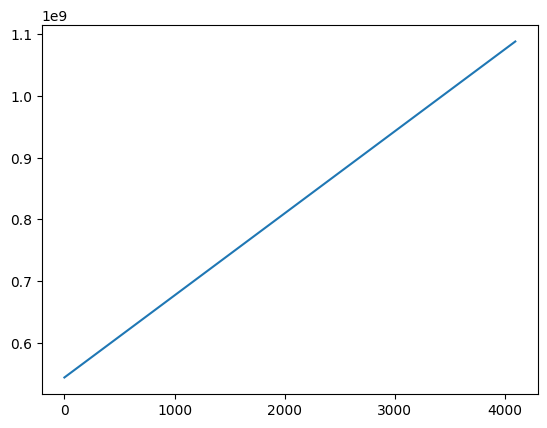

In [10]:
plt.plot(freqs)

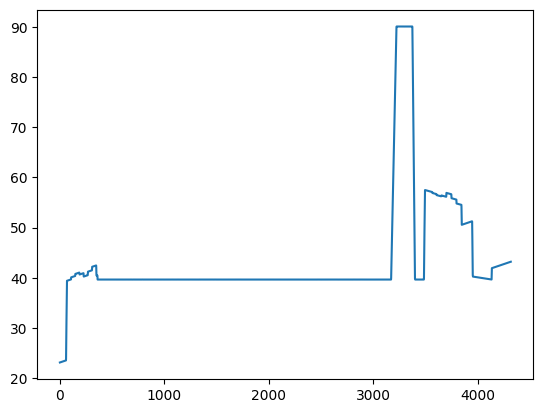

In [11]:
plt.plot(d.el[5:,10])

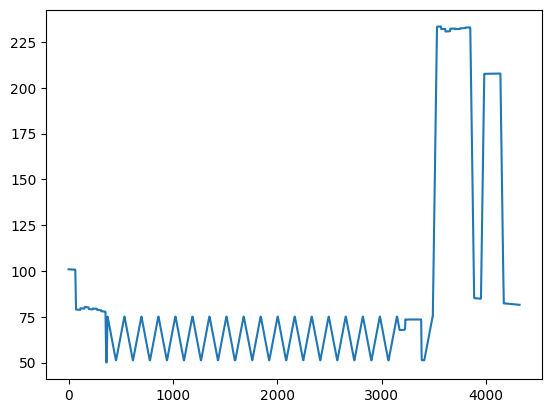

In [12]:
plt.plot(d.az[:,0])

/home/mgrsantos/envs/museek/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/mgrsantos/envs/museek/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


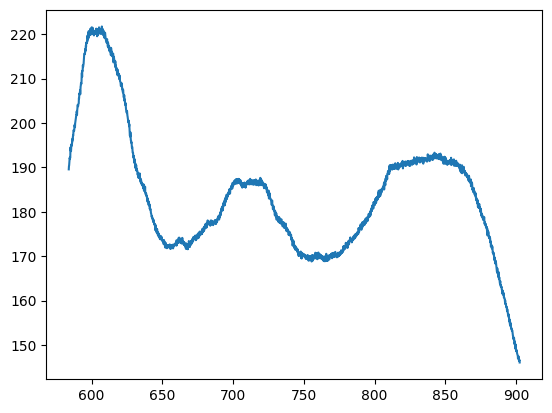

In [13]:
plt.plot(freqs[300:2700]/1.0e6, d.vis[1000,300:2700,0])

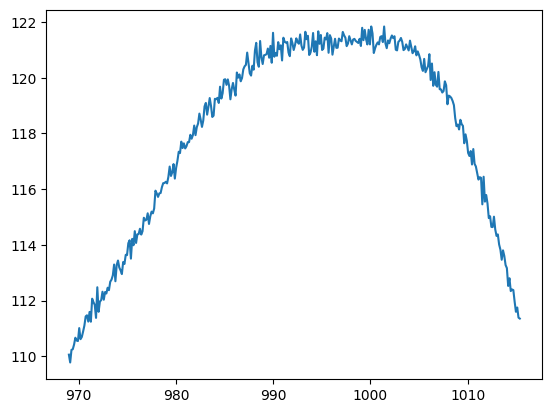

In [14]:
plt.plot(freqs[3200:3550]/1.0e6, d.vis[1000,3200:3550,0])

610.40625
1008.84375


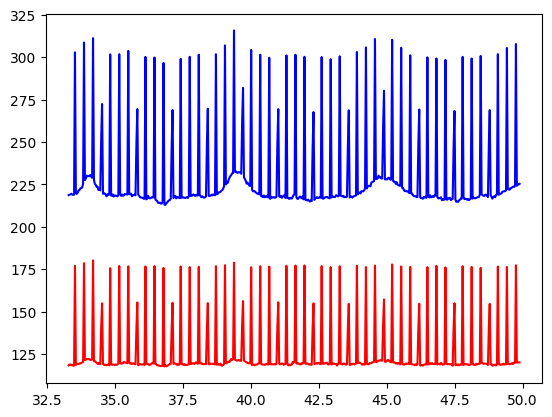

In [15]:
plt.plot((timestamps[1000:1500]-timestamps[0])/60, d.vis[1000:1500,500,0],'b')
print(freqs[500]/1.0e6)
plt.plot((timestamps[1000:1500]-timestamps[0])/60, d.vis[1000:1500,3500,0],'r')
print(freqs[3500]/1.0e6)
#plt.ylim(150,180)

162.88472183284026
172.52964560297423


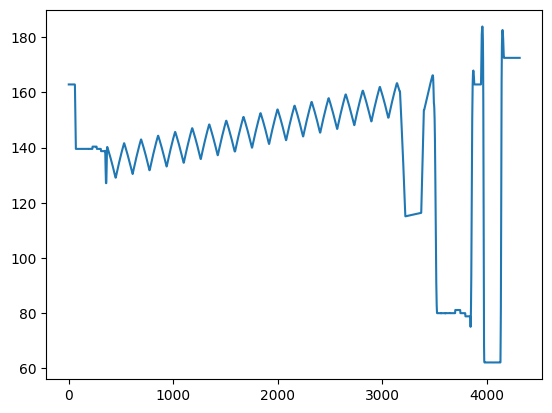

In [16]:
plt.plot(d.ra[5:,10])
print(d.ra[5,10])
print(d.ra[-1,10])

-20.396720396459628
-14.823959402099094


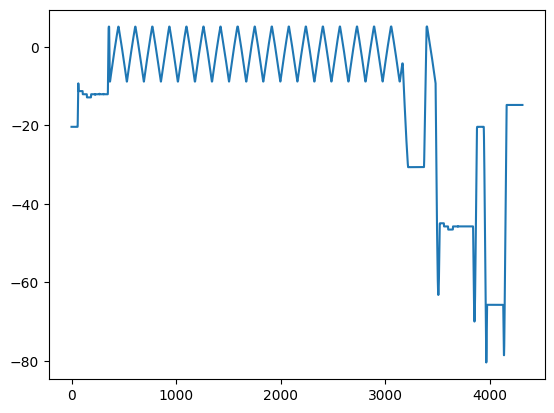

In [17]:
plt.plot(d.dec[5:,10])
print(d.dec[5,10])
print(d.dec[-1,10])

In [18]:
d.select(corrprods='auto', scans='track', strict=True)
print(np.shape(d))
print(np.shape(d.az))

(np.int64(924), np.int64(4096), np.int64(248))
(924, 62)


In [19]:
for index, state, target in d.scans():
    print(target)

J1051-2023, tags=radec gaincal, 10:51:32.17 -20:23:47.4, no flux info
HydraA_u0.8, tags=radec target, 9:18:05.67 -11:17:44.0, no flux info
HydraA_u0.8, tags=radec target, 9:18:05.67 -11:17:44.0, no flux info
HydraA, tags=radec target, 9:18:05.67 -12:05:44.0, no flux info
HydraA, tags=radec target, 9:18:05.67 -12:05:44.0, no flux info
HydraA_d0.8, tags=radec target, 9:18:05.67 -12:53:44.0, no flux info
HydraA_d0.8, tags=radec target, 9:18:05.67 -12:53:44.0, no flux info
HydraA, tags=radec target, 9:18:05.67 -12:05:44.0, no flux info
HydraA, tags=radec target, 9:18:05.67 -12:05:44.0, no flux info
HydraA_r0.8, tags=radec target, 9:21:22.03 -12:05:39.6, no flux info
HydraA_r0.8, tags=radec target, 9:21:22.03 -12:05:39.6, no flux info
HydraA, tags=radec target, 9:18:05.67 -12:05:44.0, no flux info
HydraA, tags=radec target, 9:18:05.67 -12:05:44.0, no flux info
HydraA_l0.8, tags=radec target, 9:14:49.31 -12:05:39.6, no flux info
scan_azel_with_nd_trigger, tags=azel, 50:06:41.3 40:27:00.5, no

In [20]:
azmedian=(np.median(d.az, axis=1))

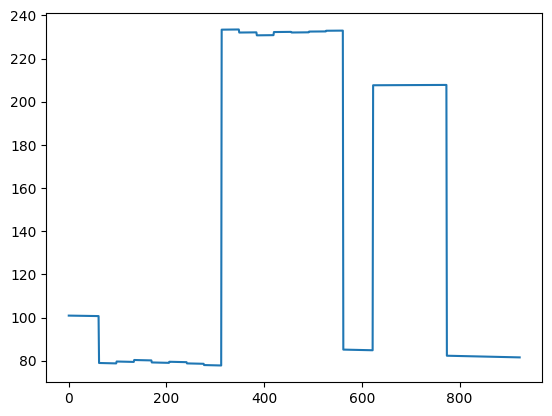

In [21]:
plt.plot(d.az[:,10])

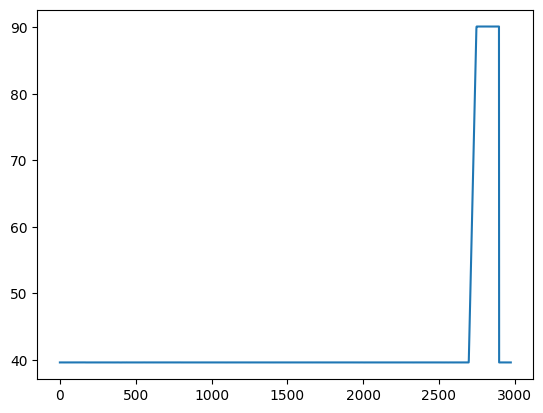

In [32]:
plt.plot(d.el[:,10])

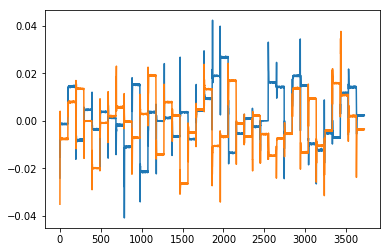

In [16]:
plt.plot(d.az[:,0]-azmedian)
plt.plot(d.az[:,1]-azmedian)

In [17]:
(d.az[:,:]-azmedian[:,None]).shape

(3724, 61)

In [19]:
print(d.az[:,1]-azmedian)

[-0.03510099 -0.01076726 -0.00046827 ... -0.00361819 -0.00370521
 -0.00357032]


In [20]:
azdev=np.average(np.absolute((d.az[:,:]-azmedian[:,None])/azmedian[:,None]),axis=0)

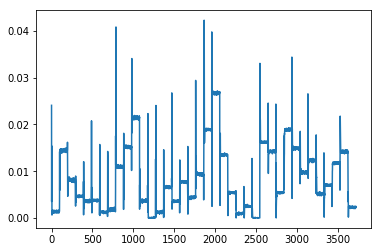

In [21]:
plt.plot((np.absolute(d.az[:,:]-azmedian[:,None]))[:,0])

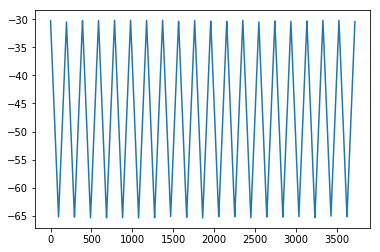

In [22]:
plt.plot(azmedian)

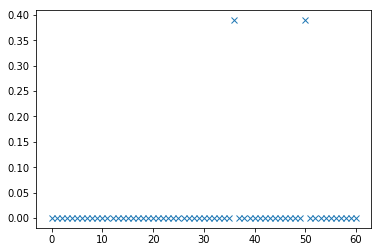

In [23]:
plt.plot(azdev,'x')

In [24]:
print((azdev > 0.01).sum())

2


In [25]:
print((np.asarray(azdev > 0.01).nonzero())[0])

[36 50]


In [26]:
print(((np.asarray(azdev > 0.01).nonzero())[0])[0])

36


In [9]:
d.select(scans='scan', corrprods='auto', strict=True)
print(np.shape(d.vis))
print(np.shape(d.flags))

(3591, 4096, 244)
(3591, 4096, 244)


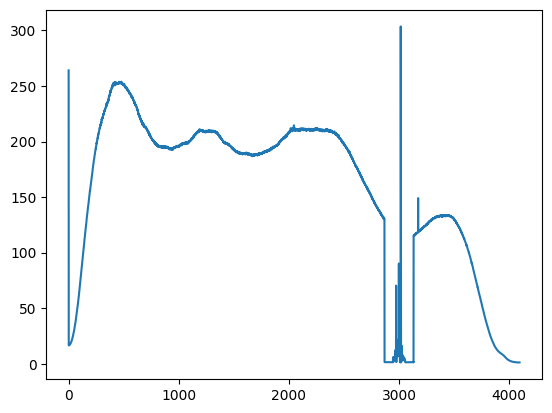

In [13]:
plt.plot(np.real(d.vis[5,:,0]))

In [ ]:
med_freq = np.median(np.real(d.vis[:,:,:]), axis=(0,2))
max_freq = np.max(np.real(d.vis[:,:,:]), axis=(0,2))

In [ ]:
plt.plot(med_freq)

In [ ]:
plt.plot(max_freq)

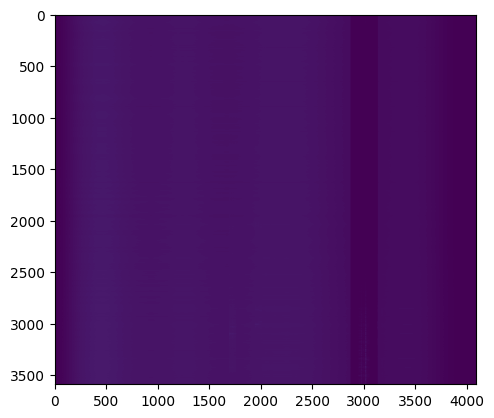

In [15]:
plt.imshow(np.real(d.vis[:,:,0]))

In [29]:
dv=np.copy(np.squeeze(d.vis[:,:,0:40]).real)
#df=np.copy(np.squeeze(d.flags[:]))

In [34]:
dvt=np.median(dv, axis=1)

In [36]:
dvnu=np.median(dv, axis=0)

In [56]:
dvtm=np.min(dv[:,500:2000,:], axis=1)

In [38]:
dvnum=np.amin(dv, axis=0)

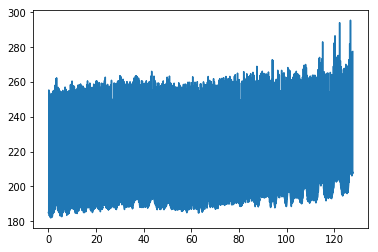

In [46]:
plt.plot((d.timestamps-d.timestamps[0])/60,dvt[:,0])

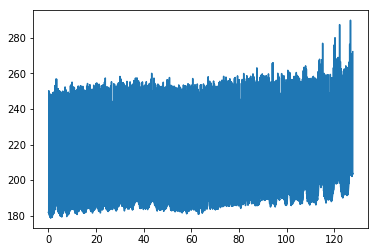

In [58]:
plt.plot((d.timestamps-d.timestamps[0])/60,dvtm[:,0])

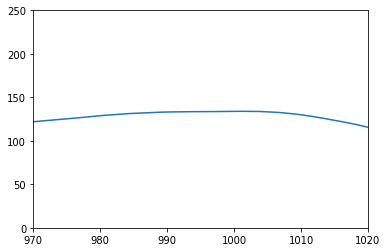

In [61]:
plt.plot(d.freqs/1.0e6,dvnu[:,0])
plt.axis((970, 1020, 0, 250))
plt.show()

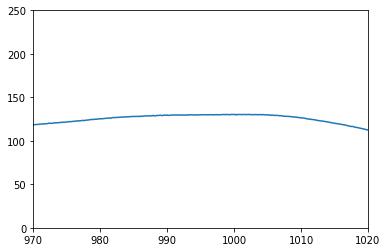

In [62]:
plt.plot(d.freqs/1.0e6,dvnum[:,0])
plt.axis((970, 1020, 0, 250))
plt.show()

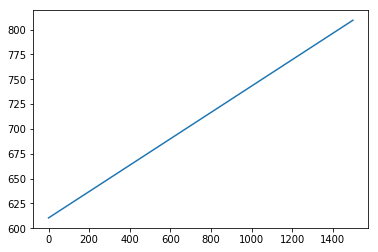

In [55]:
plt.plot(d.freqs[500:2000]/1.0e6)

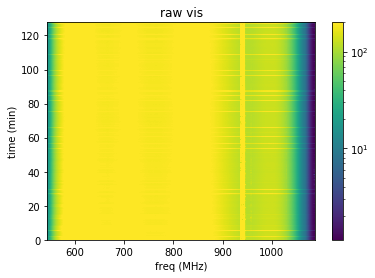

In [65]:
#plt.figure(figsize=(7.5,5.4))
plt.imshow(dv[:,:,0], vmax=200, norm=LogNorm(), extent=[d.freqs[0]/1.0e6, d.freqs[-1]/1.0e6, 0, (d.timestamps[-1]-d.timestamps[0])/60], aspect='auto')
plt.ylabel('time (min)')
plt.xlabel('freq (MHz)')
plt.title('raw vis')
plt.colorbar()
#plt.colorbar(label='Log10')
plt.show()

In [67]:
import pickle

In [31]:
print(timestamps)

[1.68564172e+09 1.68564172e+09 1.68564172e+09 ... 1.68565154e+09
 1.68565154e+09 1.68565155e+09]


In [71]:
data_h = pickle.load(open('/idia/projects/hi_im/raw_vis/SCI-20210212-MS-01/1630519596/1630519596_m000h_vis_data','rb'), encoding='latin1')

In [72]:
? data_h

Type:        dict
String form:
{'vis': array([[366.29751587,  62.51673126,  62.47373581, ...,   0.        ,
           0.         <...> True,  True, ...,  True,  True,  True],
           [ True,  True,  True, ...,  True,  True,  True]])}
Length:      3
Docstring:  
dict() -> new empty dictionary
dict(mapping) -> new dictionary initialized from a mapping object's
    (key, value) pairs
dict(iterable) -> new dictionary initialized as if via:
    d = {}
    for k, v in iterable:
        d[k] = v
dict(**kwargs) -> new dictionary initialized with the name=value pairs
    in the keyword argument list.  For example:  dict(one=1, two=2)


In [15]:
? d.JSON

Object ` d.JSON` not found.


In [14]:
d.select(corrprods='auto', scans='scan', strict=True)
print(np.shape(d))

(3177, 4096, 252)


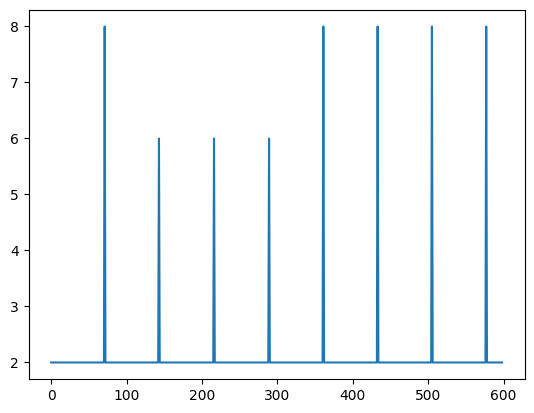

In [17]:
plt.plot(d.timestamps[1:600]-d.timestamps[0:599])

In [14]:
dt1=np.average(d.vis[:,1000:2000,0].real,axis=1)

In [15]:
dt2=np.average(d.vis[:,1000:2000,47].real,axis=1)

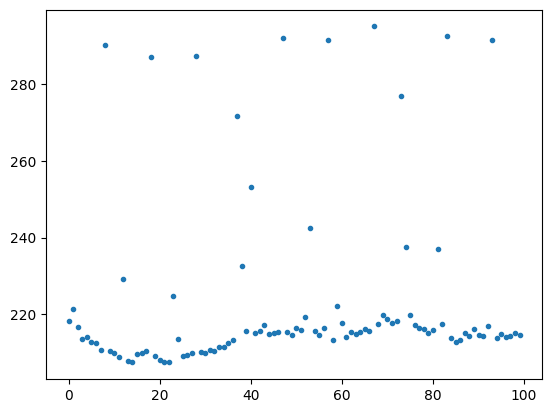

In [16]:
plt.plot(dt1[0:100],'.')

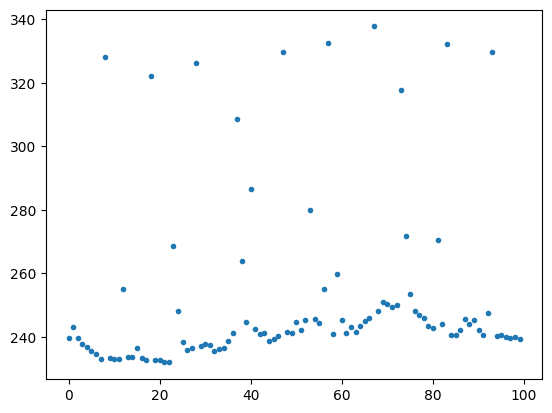

In [17]:
plt.plot(dt2[0:100],'.')

In [18]:
ind=np.where(dt1>240)
print(ind)

(array([   8,   18,   28,   37,   40,   47,   53,   57,   67,   73,   83,
         93,  103,  112,  122,  132,  142,  148,  149,  159,  169,  179,
        188,  198,  201,  208,  225,  235,  245,  255,  264,  268,  274,
        284,  292,  301,  311,  321,  328,  331,  340,  350,  360,  367,
        376,  386,  396,  406,  415,  416,  418,  425,  442,  451,  452,
        461,  471,  481,  486,  490,  500,  506,  507,  517,  526,  536,
        546,  556,  565,  575,  582,  592,  601,  611,  621,  631,  640,
        658,  662,  668,  677,  687,  697,  707,  716,  717,  724,  734,
        744,  753,  763,  773,  783,  792,  793,  799,  809,  819,  828,
        838,  848,  858,  874,  884,  894,  903,  913,  923,  933,  939,
        949,  959,  969,  978,  988,  998, 1008, 1014, 1015, 1024, 1034,
       1044, 1053, 1063, 1073, 1089, 1099, 1109, 1119, 1128, 1129, 1138,
       1145, 1148, 1156, 1165, 1166, 1175, 1185, 1195, 1204, 1214, 1224,
       1232, 1241, 1251, 1261, 1271, 1280, 1281, 1

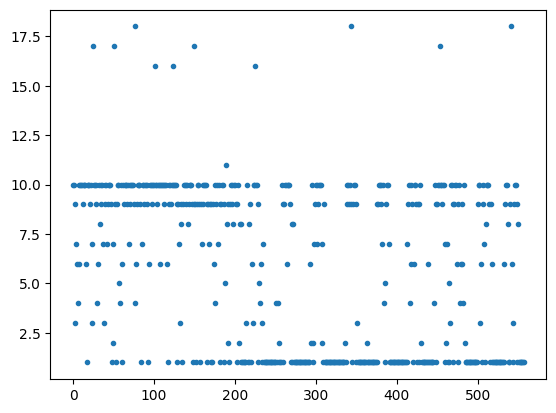

In [20]:
plt.plot(ind[0][1:]-ind[0][0:-1],'.')